## Purpose of the notebook 

This notebook is about getting the players's info and calculating trends based on that to have a table which will compute and feed the algorithm of picking the best players according to the costs

In [5]:
#Import Libraries
import os
import sqlite3
import pandas as pd
from scipy import stats
#import lux
pd.options.display.max_rows = 999
pd.options.display.max_columns = 60

In [6]:
os.getcwd()

'/Users/ziadNader/Desktop/Personal Projects/Fantasy Premier League/Notebooks'

In [7]:
#Creata SQL query
#%%
#Establish the conectionCreate your connection.
cnx = sqlite3.connect('../Data/SQLDB/fpl.db')
players_df = pd.read_sql_query("SELECT * FROM PLAYERS", cnx)
teams_df = pd.read_sql_query("SELECT * FROM TEAMS", cnx)

In [8]:
start_PL_date = '2020-09-12'
today_date = '2021-01-10'

In [9]:
players_df.shape

(10646, 54)

In [10]:
players_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10646 entries, 0 to 10645
Data columns (total 54 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   assists                       10646 non-null  int64  
 1   bonus                         10646 non-null  int64  
 2   bps                           10646 non-null  int64  
 3   chance_of_playing_next_round  5496 non-null   float64
 4   chance_of_playing_this_round  5202 non-null   float64
 5   clean_sheets                  10646 non-null  int64  
 6   code                          10646 non-null  int64  
 7   cost_change_event             10646 non-null  int64  
 8   cost_change_event_fall        10646 non-null  int64  
 9   cost_change_start             10646 non-null  int64  
 10  cost_change_start_fall        10646 non-null  int64  
 11  creativity                    10646 non-null  float64
 12  dreamteam_count               10646 non-null  int64  
 13  e

### Trend analysis 

In [11]:
players_df['date'] = pd.to_datetime(players_df['date'])

In [12]:
players_df_ts = players_df.set_index('date').sort_index()

<AxesSubplot:xlabel='date'>

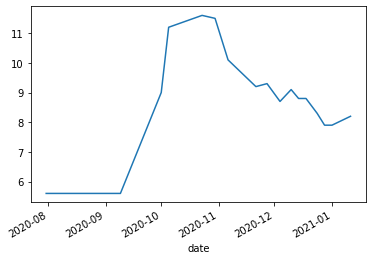

In [13]:
players_df_ts[players_df_ts['web_name']=='Son']['points_per_game'].plot()

<AxesSubplot:xlabel='date'>

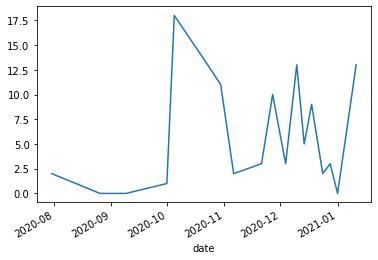

In [14]:
players_df_ts[players_df_ts['web_name']=='Son']['event_points'].plot()

<AxesSubplot:xlabel='date'>

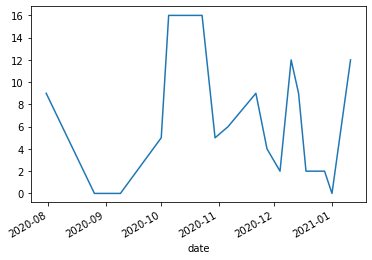

In [15]:
players_df_ts[players_df_ts['web_name']=='Kane']['event_points'].plot()

<AxesSubplot:xlabel='date'>

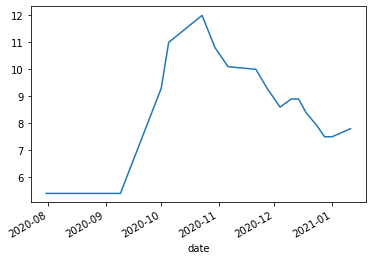

In [16]:
players_df_ts[players_df_ts['web_name']=='Kane']['points_per_game'].plot()

In [17]:
players_df_ts.index.max()

Timestamp('2021-01-11 00:00:00')

In [18]:
players_df_ts.index.value_counts(dropna=False)

2020-07-31    666
2021-01-11    625
2021-01-01    616
2020-12-28    614
2020-12-24    611
2020-12-14    607
2020-12-18    607
2020-12-10    604
2020-12-04    603
2020-11-27    601
2020-11-21    600
2020-11-06    597
2020-10-30    590
2020-10-23    588
2020-10-05    562
2020-10-01    556
2020-09-09    511
2020-08-26    488
Name: date, dtype: int64

In [21]:
players_df_ts.head()

,assists,bonus,bps,chance_of_playing_next_round,chance_of_playing_this_round,clean_sheets,code,cost_change_event,cost_change_event_fall,cost_change_start,cost_change_start_fall,creativity,dreamteam_count,element_type,ep_next,ep_this,event_points,first_name,form,goals_conceded,goals_scored,ict_index,i_d,in_dreamteam,influence,minutes,news,news_added,now_cost,own_goals,penalties_missed,penalties_saved,photo,points_per_game,red_cards,saves,second_name,selected_by_percent,special,squad_number,status,team,team_code,threat,total_points,transfers_in,transfers_in_event,transfers_out,transfers_out_event,value_form,value_season,web_name,yellow_cards
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020-07-31,2,2,242,0.0,0.0,4,69140,0,0,-4,4,45.5,0,2,0.0,0.0,0,Shkodran,1.4,17,0,47.9,1,0,277.2,1205,Hamstring injury - Expected back 31 Oct,2020-07-18T22:30:20.553834Z,51,0,0,0,69140.jpg,2.9,0,0,Mustafi,0.4,0,None,i,1,3,155.0,43,25007,0,47630,0,0.3,8.4,Mustafi,2
2020-07-31,1,0,424,100.0,100.0,5,78607,0,0,-2,2,423.9,0,3,0.0,0.1,2,Kenny,1.6,63,1,120.4,286,0,505.8,2965,None,2020-07-10T22:30:16.780744Z,48,0,0,0,78607.jpg,2.1,0,0,McLean,0.1,0,None,a,14,45,274.0,77,13552,0,19029,0,0.3,16.0,McLean,5
2020-07-31,2,10,410,100.0,100.0,6,193111,0,0,0,0,493.1,2,3,-0.5,-0.4,2,Todd,1.1,54,6,165.9,287,0,516.4,2484,None,2020-07-06T13:00:16.080743Z,45,0,0,0,193111.jpg,3.0,0,0,Cantwell,13.0,0,None,a,14,45,656.0,111,3957013,0,3213559,0,0.2,24.7,Cantwell,6
2020-07-31,0,0,102,0.0,0.0,1,87396,0,0,-2,2,127.7,0,3,0.0,0.0,0,Moritz,0.0,16,0,28.8,288,0,106.8,683,Hernia - Unknown return date,2020-06-30T13:00:23.430220Z,43,0,0,0,87396.jpg,1.8,0,0,Leitner,0.2,0,None,i,14,45,53.0,16,26649,0,36025,0,0.0,3.7,Leitner,1
2020-07-31,1,3,404,0.0,0.0,5,18665,0,0,-1,1,116.5,0,3,0.0,0.0,0,Alexander,1.4,44,1,64.9,289,0,358.0,2339,Knee injury - Unknown return date,2020-07-24T12:00:20.187363Z,44,0,0,0,18665.jpg,2.2,0,0,Tettey,0.3,0,None,i,14,45,173.0,67,55603,0,51452,0,0.3,15.2,Tettey,5


In [24]:
players_df_ts.loc[players_df_ts.index.max()]

,assists,bonus,bps,chance_of_playing_next_round,chance_of_playing_this_round,clean_sheets,code,cost_change_event,cost_change_event_fall,cost_change_start,cost_change_start_fall,creativity,dreamteam_count,element_type,ep_next,ep_this,event_points,first_name,form,goals_conceded,goals_scored,ict_index,i_d,in_dreamteam,influence,minutes,news,news_added,now_cost,own_goals,penalties_missed,penalties_saved,photo,points_per_game,red_cards,saves,second_name,selected_by_percent,special,squad_number,status,team,team_code,threat,total_points,transfers_in,transfers_in_event,transfers_out,transfers_out_event,value_form,value_season,web_name,yellow_cards
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2021-01-11,0,0,47,100.0,100.0,1,50472,-1,1,-2,2,25.0,0,3,-0.5,0.0,0,James,0.0,5,0,8.5,131,0,52.2,329,None,2020-10-14T10:00:21.275991Z,43,0,0,0,50472.jpg,1.8,0,0,McCarthy,1.1,0,None,a,6,31,8.0,9,118429,2649,221782,3816,0.0,2.1,McCarthy,1
2021-01-11,0,0,0,0.0,0.0,0,58786,0,0,-4,4,0.0,0,2,0.0,0.0,0,Martin,0.0,0,0,0.0,135,0,0.0,0,Calf injury - Unknown return date,2020-12-04T19:00:20.235749Z,41,0,0,0,58786.jpg,0.0,0,0,Kelly,0.3,0,None,i,6,31,0.0,0,9344,58,75962,836,0.0,0.0,Kelly,0
2021-01-11,1,2,111,100.0,100.0,2,55494,0,0,-2,2,51.0,0,2,1.7,2.2,7,Joel,2.2,12,0,20.1,134,0,141.0,720,None,2020-10-29T14:30:19.985440Z,43,0,0,0,55494.jpg,2.8,0,0,Ward,0.8,0,None,a,6,31,9.0,22,72767,6194,151570,2540,0.5,5.1,Ward,3
2021-01-11,0,2,224,NaN,NaN,2,55037,0,0,0,0,54.4,0,3,1.7,2.2,3,Cheikhou,2.2,26,1,47.5,133,0,303.0,1502,None,None,50,0,0,0,55037.jpg,2.5,0,0,Kouyaté,0.5,0,None,a,6,31,116.0,43,78545,2188,74574,2303,0.4,8.6,Kouyaté,0
2021-01-11,3,6,206,NaN,NaN,3,60252,0,0,-3,3,377.2,0,3,1.8,2.3,3,Andros,2.3,15,1,80.3,137,0,277.6,1110,None,None,57,0,0,0,60252.jpg,3.4,0,0,Townsend,1.4,0,None,a,6,31,146.0,51,388609,2238,380541,5014,0.4,8.9,Townsend,0
2021-01-11,1,3,83,100.0,100.0,0,54861,0,0,0,0,90.9,1,4,1.7,2.2,4,Christian,2.2,10,3,54.6,132,0,138.8,534,None,2021-01-02T17:30:14.117437Z,55,0,0,0,54861.jpg,2.7,1,0,Benteke,0.7,0,None,a,6,31,318.0,32,87853,6690,61534,10501,0.4,5.8,Benteke,0
2021-01-11,0,0,0,0.0,0.0,0,59125,0,0,-1,1,0.0,0,4,0.0,0.0,0,Connor,0.0,0,0,0.0,136,0,0.0,0,Muscle injury - Unknown return date,2020-09-06T03:00:11.034332Z,44,0,0,0,59125.jpg,0.0,0,0,Wickham,0.6,0,None,i,6,31,0.0,0,47500,3709,101038,2894,0.0,0.0,Wickham,0
2021-01-11,0,0,0,0.0,0.0,0,20066,0,0,-2,2,0.0,0,1,0.0,0.0,0,Wayne,0.0,0,0,0.0,126,0,0.0,0,Muscle injury - Unknown return date,2020-10-15T01:00:16.946989Z,43,0,0,0,20066.jpg,0.0,0,0,Hennessey,0.3,0,None,i,6,31,0.0,0,6593,50,42903,700,0.0,0.0,Hennessey,0
2021-01-11,0,2,40,100.0,100.0,1,49413,0,0,0,0,0.4,0,2,1.2,1.7,8,James,1.7,4,0,3.5,129,0,32.6,207,None,2020-11-06T15:00:15.437586Z,45,0,0,0,49413.jpg,3.3,0,0,Tomkins,0.1,0,None,a,6,31,2.0,10,4953,1478,3011,639,0.4,2.2,Tomkins,0


In [27]:
players_df_ts.loc[players_df_ts.index.max()].nlargest(10, 'selected_by_percent')

,assists,bonus,bps,chance_of_playing_next_round,chance_of_playing_this_round,clean_sheets,code,cost_change_event,cost_change_event_fall,cost_change_start,cost_change_start_fall,creativity,dreamteam_count,element_type,ep_next,ep_this,event_points,first_name,form,goals_conceded,goals_scored,ict_index,i_d,in_dreamteam,influence,minutes,news,news_added,now_cost,own_goals,penalties_missed,penalties_saved,photo,points_per_game,red_cards,saves,second_name,selected_by_percent,special,squad_number,status,team,team_code,threat,total_points,transfers_in,transfers_in_event,transfers_out,transfers_out_event,value_form,value_season,web_name,yellow_cards
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2021-01-11,5,18,423,100.0,100.0,8,85971,1,-1,8,-8,445.0,7,3,6.9,6.9,13,Heung-Min,6.4,9,12,156.5,390,1,611.6,1346,None,2020-09-27T16:00:17.251688Z,98,0,0,0,85971.jpg,8.2,0,0,Son,63.4,0,None,a,17,6,506.0,132,5752652,101930,3264735,61904,0.7,13.5,Son,0
2021-01-11,8,22,463,NaN,NaN,4,141746,1,-1,8,-8,729.5,6,3,9.3,8.8,10,Bruno Miguel,8.3,19,11,200.9,302,1,716.4,1299,None,None,113,0,1,0,141746.jpg,8.1,0,0,Borges Fernandes,53.5,0,None,a,13,1,561.0,130,4228567,206496,1605457,13684,0.7,11.5,Fernandes,3
2021-01-11,4,10,339,NaN,NaN,5,177815,-1,1,8,-8,145.7,2,4,3.4,3.4,2,Dominic,3.4,19,11,137.3,164,0,457.8,1405,None,None,78,0,0,0,177815.jpg,5.9,0,0,Calvert-Lewin,52.7,0,None,a,7,11,772.0,95,5017892,61343,1936410,270694,0.4,12.2,Calvert-Lewin,3
2021-01-11,11,21,444,100.0,100.0,6,78830,0,0,5,-5,309.0,5,4,5.9,5.9,12,Harry,5.4,14,10,168.0,388,1,666.2,1429,None,2020-12-02T13:00:19.592396Z,110,0,0,0,78830.jpg,7.8,0,0,Kane,45.1,0,None,a,17,6,705.0,125,3673853,158412,1770680,53324,0.5,11.4,Kane,1
2021-01-11,5,13,326,NaN,NaN,6,106617,0,0,11,-11,113.3,2,4,0.0,4.7,2,Patrick,5.2,31,10,141.1,202,1,433.8,1456,None,None,66,0,0,0,106617.jpg,5.9,0,0,Bamford,42.6,0,None,a,10,2,862.0,101,4705770,140086,1702625,213286,0.8,15.3,Bamford,1
2021-01-11,9,11,374,NaN,NaN,8,114283,0,0,7,-7,700.6,2,3,3.8,3.8,7,Jack,4.3,16,5,192.5,37,1,502.8,1350,None,None,77,0,0,0,114283.jpg,6.5,0,0,Grealish,37.7,0,None,a,2,7,724.0,97,4263480,109380,2253173,103327,0.6,12.6,Grealish,4
2021-01-11,4,13,375,100.0,100.0,4,118748,-1,1,5,-5,398.0,3,3,0.0,7.3,2,Mohamed,6.3,20,13,180.5,254,1,603.8,1348,None,2020-11-13T15:30:16.171973Z,125,0,0,0,118748.jpg,7.8,0,0,Salah,35.7,0,None,a,11,14,804.0,125,3534930,32617,2946771,388931,0.5,10.0,Salah,0
2021-01-11,0,10,351,NaN,NaN,8,98980,1,-1,6,-6,0.0,1,1,6.3,6.3,3,Emiliano,6.8,16,0,39.3,12,1,394.8,1350,None,None,51,0,0,1,98980.jpg,5.5,0,52,Martínez,29.6,0,None,a,2,7,0.0,83,2576418,149188,843093,43696,1.3,16.3,Martínez,0
2021-01-11,8,11,302,100.0,100.0,7,61366,0,0,2,-2,649.6,2,3,6.6,6.1,13,Kevin,5.6,11,3,159.4,272,0,426.6,1187,None,2020-10-12T20:30:22.007151Z,117,0,1,0,61366.jpg,5.8,0,0,De Bruyne,27.4,0,None,a,12,43,516.0,81,3365526,311845,3610664,32395,0.5,6.9,De Bruyne,1


In [28]:
players_df_ts.loc[players_df_ts.index.max()].nlargest(10, 'points_per_game')\
[['first_name', 'web_name', 'team_code','points_per_game','minutes']]

,first_name,web_name,team_code,points_per_game,minutes
date,,,,,
2021-01-11,Heung-Min,Son,6,8.2,1346
2021-01-11,Bruno Miguel,Fernandes,1,8.1,1299
2021-01-11,Harry,Kane,6,7.8,1429
2021-01-11,Mohamed,Salah,14,7.8,1348
2021-01-11,Jamie,Vardy,13,7.0,1299
2021-01-11,Caoimhin,Kelleher,14,7.0,90
2021-01-11,Kortney,Hause,7,7.0,360
2021-01-11,Jack,Grealish,7,6.5,1350
2021-01-11,Callum,Wilson,4,6.1,1237


### Calculate trends in differents areas : 

* Points per game 
* Total Points
* Form 
* Cost

In [29]:
players_df_2021 = players_df_ts.loc[start_PL_date:]

In [30]:
trend_df = players_df_2021.groupby(['first_name', 'web_name'])['total_points'].diff().rename('trend_diff').reset_index()

In [31]:
g = players_df_2021.groupby(['first_name', 'web_name'])['total_points'].diff().reset_index(name='t')
#g['trend'] = df.groupby('c')['type'].transform('size')

In [32]:
players_df_2021.head()

,assists,bonus,bps,chance_of_playing_next_round,chance_of_playing_this_round,clean_sheets,code,cost_change_event,cost_change_event_fall,cost_change_start,cost_change_start_fall,creativity,dreamteam_count,element_type,ep_next,ep_this,event_points,first_name,form,goals_conceded,goals_scored,ict_index,i_d,in_dreamteam,influence,minutes,news,news_added,now_cost,own_goals,penalties_missed,penalties_saved,photo,points_per_game,red_cards,saves,second_name,selected_by_percent,special,squad_number,status,team,team_code,threat,total_points,transfers_in,transfers_in_event,transfers_out,transfers_out_event,value_form,value_season,web_name,yellow_cards
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020-10-01,0,0,0,NaN,NaN,0,37605,-1,1,-2,2,0.0,0,3,0.5,-0.5,0,Mesut,0.0,0,0,0.0,1,0,0.0,0,None,None,68,0,0,0,37605.jpg,0.0,0,0,Özil,0.8,0,None,a,1,3,0.0,0,2157,487,33983,4034,0.0,0.0,Özil,0
2020-10-01,0,0,8,NaN,NaN,1,27436,0,0,-1,1,14.9,0,4,0.8,1.8,2,David,1.3,0,0,3.1,344,0,2.6,122,None,None,54,0,0,0,27436.jpg,1.3,0,0,McGoldrick,0.7,0,None,a,15,49,13.0,4,13287,2480,37200,7444,0.2,0.7,McGoldrick,0
2020-10-01,0,0,48,NaN,NaN,1,109528,0,0,0,0,25.1,0,2,2.7,2.2,2,Javier,2.7,4,0,6.4,332,0,35.0,270,None,None,45,0,0,0,109528.jpg,2.7,0,0,Manquillo,0.4,0,None,a,14,4,4.0,8,8827,1486,8623,1601,0.6,1.8,Manquillo,1
2020-10-01,0,0,0,50.0,0.0,0,106618,-1,1,-1,1,0.0,0,2,0.0,0.0,0,Paul,0.0,0,0,0.0,331,0,0.0,0,Lack of match fitness - 50% chance of playing,2020-09-06T00:30:15.468275Z,44,0,0,0,106618.jpg,0.0,0,0,Dummett,0.0,0,None,d,14,4,0.0,0,54,8,882,117,0.0,0.0,Dummett,0
2020-10-01,0,0,0,NaN,NaN,0,104953,0,0,-1,1,0.0,0,3,0.0,-0.5,0,Christian,0.0,0,0,0.0,330,0,0.0,0,None,None,54,0,0,0,104953.jpg,0.0,0,0,Atsu,0.1,0,None,a,14,4,0.0,0,610,136,3097,458,0.0,0.0,Atsu,0


In [33]:
players_df_2021.groupby(['first_name', 'web_name'])['total_points'].diff().rename('trend_diff').reset_index()

,date,trend_diff
0,2020-10-01,NaN
1,2020-10-01,NaN
2,2020-10-01,NaN
3,2020-10-01,NaN
4,2020-10-01,NaN
...,...,...
8976,2021-01-11,0.0
8977,2021-01-11,2.0
8978,2021-01-11,0.0
8979,2021-01-11,1.0


In [34]:
players_df_2021.head()

,assists,bonus,bps,chance_of_playing_next_round,chance_of_playing_this_round,clean_sheets,code,cost_change_event,cost_change_event_fall,cost_change_start,cost_change_start_fall,creativity,dreamteam_count,element_type,ep_next,ep_this,event_points,first_name,form,goals_conceded,goals_scored,ict_index,i_d,in_dreamteam,influence,minutes,news,news_added,now_cost,own_goals,penalties_missed,penalties_saved,photo,points_per_game,red_cards,saves,second_name,selected_by_percent,special,squad_number,status,team,team_code,threat,total_points,transfers_in,transfers_in_event,transfers_out,transfers_out_event,value_form,value_season,web_name,yellow_cards
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020-10-01,0,0,0,NaN,NaN,0,37605,-1,1,-2,2,0.0,0,3,0.5,-0.5,0,Mesut,0.0,0,0,0.0,1,0,0.0,0,None,None,68,0,0,0,37605.jpg,0.0,0,0,Özil,0.8,0,None,a,1,3,0.0,0,2157,487,33983,4034,0.0,0.0,Özil,0
2020-10-01,0,0,8,NaN,NaN,1,27436,0,0,-1,1,14.9,0,4,0.8,1.8,2,David,1.3,0,0,3.1,344,0,2.6,122,None,None,54,0,0,0,27436.jpg,1.3,0,0,McGoldrick,0.7,0,None,a,15,49,13.0,4,13287,2480,37200,7444,0.2,0.7,McGoldrick,0
2020-10-01,0,0,48,NaN,NaN,1,109528,0,0,0,0,25.1,0,2,2.7,2.2,2,Javier,2.7,4,0,6.4,332,0,35.0,270,None,None,45,0,0,0,109528.jpg,2.7,0,0,Manquillo,0.4,0,None,a,14,4,4.0,8,8827,1486,8623,1601,0.6,1.8,Manquillo,1
2020-10-01,0,0,0,50.0,0.0,0,106618,-1,1,-1,1,0.0,0,2,0.0,0.0,0,Paul,0.0,0,0,0.0,331,0,0.0,0,Lack of match fitness - 50% chance of playing,2020-09-06T00:30:15.468275Z,44,0,0,0,106618.jpg,0.0,0,0,Dummett,0.0,0,None,d,14,4,0.0,0,54,8,882,117,0.0,0.0,Dummett,0
2020-10-01,0,0,0,NaN,NaN,0,104953,0,0,-1,1,0.0,0,3,0.0,-0.5,0,Christian,0.0,0,0,0.0,330,0,0.0,0,None,None,54,0,0,0,104953.jpg,0.0,0,0,Atsu,0.1,0,None,a,14,4,0.0,0,610,136,3097,458,0.0,0.0,Atsu,0


In [35]:
players_df_2021['diff'] = players_df_2021.groupby(['first_name', 'web_name'])['total_points'].diff().fillna(0)

<ipython-input-35-26914423ce0d>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  players_df_2021['diff'] = players_df_2021.groupby(['first_name', 'web_name'])['total_points'].diff().fillna(0)


In [36]:
players_df_2021.head()

,assists,bonus,bps,chance_of_playing_next_round,chance_of_playing_this_round,clean_sheets,code,cost_change_event,cost_change_event_fall,cost_change_start,cost_change_start_fall,creativity,dreamteam_count,element_type,ep_next,ep_this,event_points,first_name,form,goals_conceded,goals_scored,ict_index,i_d,in_dreamteam,influence,minutes,news,news_added,now_cost,own_goals,penalties_missed,penalties_saved,photo,points_per_game,red_cards,saves,second_name,selected_by_percent,special,squad_number,status,team,team_code,threat,total_points,transfers_in,transfers_in_event,transfers_out,transfers_out_event,value_form,value_season,web_name,yellow_cards,diff
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020-10-01,0,0,0,NaN,NaN,0,37605,-1,1,-2,2,0.0,0,3,0.5,-0.5,0,Mesut,0.0,0,0,0.0,1,0,0.0,0,None,None,68,0,0,0,37605.jpg,0.0,0,0,Özil,0.8,0,None,a,1,3,0.0,0,2157,487,33983,4034,0.0,0.0,Özil,0,0.0
2020-10-01,0,0,8,NaN,NaN,1,27436,0,0,-1,1,14.9,0,4,0.8,1.8,2,David,1.3,0,0,3.1,344,0,2.6,122,None,None,54,0,0,0,27436.jpg,1.3,0,0,McGoldrick,0.7,0,None,a,15,49,13.0,4,13287,2480,37200,7444,0.2,0.7,McGoldrick,0,0.0
2020-10-01,0,0,48,NaN,NaN,1,109528,0,0,0,0,25.1,0,2,2.7,2.2,2,Javier,2.7,4,0,6.4,332,0,35.0,270,None,None,45,0,0,0,109528.jpg,2.7,0,0,Manquillo,0.4,0,None,a,14,4,4.0,8,8827,1486,8623,1601,0.6,1.8,Manquillo,1,0.0
2020-10-01,0,0,0,50.0,0.0,0,106618,-1,1,-1,1,0.0,0,2,0.0,0.0,0,Paul,0.0,0,0,0.0,331,0,0.0,0,Lack of match fitness - 50% chance of playing,2020-09-06T00:30:15.468275Z,44,0,0,0,106618.jpg,0.0,0,0,Dummett,0.0,0,None,d,14,4,0.0,0,54,8,882,117,0.0,0.0,Dummett,0,0.0
2020-10-01,0,0,0,NaN,NaN,0,104953,0,0,-1,1,0.0,0,3,0.0,-0.5,0,Christian,0.0,0,0,0.0,330,0,0.0,0,None,None,54,0,0,0,104953.jpg,0.0,0,0,Atsu,0.1,0,None,a,14,4,0.0,0,610,136,3097,458,0.0,0.0,Atsu,0,0.0


In [37]:
players_df_2021[players_df_2021['web_name'] == 'Son']

,assists,bonus,bps,chance_of_playing_next_round,chance_of_playing_this_round,clean_sheets,code,cost_change_event,cost_change_event_fall,cost_change_start,cost_change_start_fall,creativity,dreamteam_count,element_type,ep_next,ep_this,event_points,first_name,form,goals_conceded,goals_scored,ict_index,i_d,in_dreamteam,influence,minutes,news,news_added,now_cost,own_goals,penalties_missed,penalties_saved,photo,points_per_game,red_cards,saves,second_name,selected_by_percent,special,squad_number,status,team,team_code,threat,total_points,transfers_in,transfers_in_event,transfers_out,transfers_out_event,value_form,value_season,web_name,yellow_cards,diff
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020-10-01,0,2,98,25.0,NaN,0,85971,-1,1,0,0,109.1,1,3,2.2,9.5,1,Heung-Min,9.0,3,4,39.6,390,1,157.6,225,Hamstring injury - 25% chance of playing,2020-09-27T16:00:17.251688Z,90,0,0,0,85971.jpg,9.0,0,0,Son,22.4,0,None,d,17,6,129.0,27,1043294,64066,1456945,838209,1.0,3.0,Son,0,0.0
2020-10-05,1,5,162,100.0,25.0,0,85971,0,0,0,0,171.3,2,3,11.7,2.8,18,Heung-Min,11.2,4,6,60.2,390,1,249.0,297,None,2020-09-27T16:00:17.251688Z,90,0,0,0,85971.jpg,11.2,0,0,Son,22.2,0,None,a,17,6,181.0,45,1583672,532333,2062308,63407,1.2,5.0,Son,0,2.0
2020-10-23,2,7,197,100.0,100.0,1,85971,2,-2,4,-4,204.9,3,3,11.2,11.2,13,Heung-Min,10.7,4,7,75.4,390,1,311.0,376,None,2020-09-27T16:00:17.251688Z,94,0,0,0,85971.jpg,11.6,0,0,Son,52.9,0,None,a,17,6,237.0,58,3764918,721848,2100121,16718,1.1,6.2,Son,0,5.0
2020-10-30,2,10,227,100.0,100.0,2,85971,1,-1,5,-5,214.3,4,3,14.5,14.5,11,Heung-Min,14.0,4,8,86.1,390,1,347.2,466,None,2020-09-27T16:00:17.251688Z,95,0,0,0,85971.jpg,11.5,0,0,Son,58.1,0,None,a,17,6,298.0,69,4177619,369943,2112531,11276,1.5,7.3,Son,0,1.0
2020-11-06,2,10,236,100.0,100.0,2,85971,1,-1,6,-6,226.9,4,3,9.7,9.2,2,Heung-Min,8.7,5,8,88.2,390,1,350.8,550,None,2020-09-27T16:00:17.251688Z,96,0,0,0,85971.jpg,10.1,0,0,Son,60.3,0,None,a,17,6,303.0,71,4374034,181489,2139890,26991,0.9,7.4,Son,0,0.0
2020-11-21,2,10,244,100.0,100.0,3,85971,-1,1,5,-5,250.2,4,3,4.8,6.3,3,Heung-Min,5.3,5,8,96.4,390,1,366.2,640,None,2020-09-27T16:00:17.251688Z,95,0,0,0,85971.jpg,9.2,0,0,Son,56.5,0,None,a,17,6,346.0,74,4512725,131170,2513083,372270,0.6,7.8,Son,0,0.0
2020-11-27,2,12,273,100.0,100.0,4,85971,0,0,5,-5,252.2,5,3,5.0,4.5,10,Heung-Min,5.0,5,9,102.4,390,1,406.8,730,None,2020-09-27T16:00:17.251688Z,95,0,0,0,85971.jpg,9.3,0,0,Son,57.4,0,None,a,17,6,363.0,84,4670329,149327,2618729,76850,0.5,8.8,Son,0,0.0
2020-12-04,2,12,285,100.0,100.0,5,85971,0,0,5,-5,265.1,5,3,5.3,5.3,3,Heung-Min,5.3,5,9,104.4,390,1,409.6,820,None,2020-09-27T16:00:17.251688Z,95,0,0,0,85971.jpg,8.7,0,0,Son,57.3,0,None,a,17,6,367.0,87,4753082,76078,2714150,84579,0.6,9.2,Son,0,0.0
2020-12-10,3,14,320,100.0,100.0,6,85971,1,-1,6,-6,276.1,6,3,9.2,8.7,13,Heung-Min,8.7,5,10,111.9,390,1,464.2,907,None,2020-09-27T16:00:17.251688Z,96,0,0,0,85971.jpg,9.1,0,0,Son,59.1,0,None,a,17,6,376.0,100,4952984,167090,2786529,20611,0.9,10.4,Son,0,1.0


In [38]:
players_df_2021['diff_event_pts'] = players_df_2021.groupby(['first_name', 'web_name'])['event_points'].diff().fillna(0)

<ipython-input-38-678b70220f35>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  players_df_2021['diff_event_pts'] = players_df_2021.groupby(['first_name', 'web_name'])['event_points'].diff().fillna(0)


In [39]:
players_df_2021[players_df_2021['web_name'] == 'Son'][['diff_event_pts', 'event_points']]

,diff_event_pts,event_points
date,,
2020-10-01,0.0,1
2020-10-05,0.0,18
2020-10-23,5.0,13
2020-10-30,1.0,11
2020-11-06,0.0,2
2020-11-21,0.0,3
2020-11-27,0.0,10
2020-12-04,0.0,3
2020-12-10,0.0,13


In [40]:
(players_df_2021[players_df_2021['web_name'] == 'Saka'][['diff_event_pts', 'event_points']])

,diff_event_pts,event_points
date,,
2020-10-01,0.0,0
2020-10-05,1.0,8
2020-10-23,0.0,2
2020-10-30,2.0,3
2020-11-06,0.0,3
2020-11-21,2.0,0
2020-11-27,0.0,1
2020-12-04,0.0,2
2020-12-10,-1.0,2


In [41]:
(players_df_2021[players_df_2021['web_name'] == 'De Bruyne'][['diff_event_pts', 'event_points']])

,diff_event_pts,event_points
date,,
2020-10-01,0.0,2
2020-10-05,0.0,2
2020-10-23,0.0,0
2020-10-30,-1.0,1
2020-11-06,-1.0,6
2020-11-21,0.0,3
2020-11-27,0.0,2
2020-12-04,0.0,10
2020-12-10,-1.0,14


In [42]:
(players_df_2021[players_df_2021['web_name'] == 'Salah'][['diff_event_pts', 'event_points', 'form', 'value_form']])

,diff_event_pts,event_points,form,value_form
date,,,,
2020-10-01,0.0,5,9.3,0.8
2020-10-05,2.0,13,10.2,0.8
2020-10-23,0.0,7,8.3,0.7
2020-10-30,0.0,2,7.3,0.6
2020-11-06,0.0,8,5.7,0.5
2020-11-21,-10.0,9,6.3,0.5
2020-11-27,5.0,0,5.7,0.5
2020-12-04,0.0,6,5.0,0.4
2020-12-10,2.0,14,6.7,0.5


In [43]:
(players_df_2021[players_df_2021['web_name'] == 'Saka'][['diff_event_pts', 'event_points', 'form', 'value_form']])

,diff_event_pts,event_points,form,value_form
date,,,,
2020-10-01,0.0,0,0.7,0.1
2020-10-05,1.0,8,2.5,0.5
2020-10-23,0.0,2,3.3,0.6
2020-10-30,2.0,3,4.3,0.8
2020-11-06,0.0,3,2.7,0.5
2020-11-21,2.0,0,2.0,0.4
2020-11-27,0.0,1,1.3,0.2
2020-12-04,0.0,2,1.0,0.2
2020-12-10,-1.0,2,1.7,0.3


In [44]:
(players_df_2021[players_df_2021['web_name'] == 'De Bruyne'][['diff_event_pts', 'event_points', 'form', 'value_form']])

,diff_event_pts,event_points,form,value_form
date,,,,
2020-10-01,0.0,2,7.5,0.6
2020-10-05,0.0,2,5.7,0.5
2020-10-23,0.0,0,1.3,0.1
2020-10-30,-1.0,1,1.0,0.1
2020-11-06,-1.0,6,2.3,0.2
2020-11-21,0.0,3,3.3,0.3
2020-11-27,0.0,2,3.7,0.3
2020-12-04,0.0,10,5.0,0.4
2020-12-10,-1.0,14,8.7,0.7


In [45]:
(players_df_2021[players_df_2021['web_name'] == 'Bailly'][['diff_event_pts', 'event_points', 'form', 'value_form']])

,diff_event_pts,event_points,form,value_form
date,,,,
2020-10-01,0.0,1,0.5,0.1
2020-10-05,0.0,-2,-0.3,-0.1
2020-10-23,0.0,0,-0.3,-0.1
2020-10-30,0.0,0,-0.7,-0.1
2020-11-06,1.0,0,0.0,0.0
2020-11-21,-1.0,0,0.0,0.0
2020-11-27,-2.0,0,0.0,0.0
2020-12-04,-5.0,0,0.0,0.0
2020-12-10,0.0,0,0.0,0.0


In [46]:
(players_df_2021[players_df_2021['web_name'] == 'Cancelo'][['diff_event_pts', 'event_points', 'form', 'value_form']])

,diff_event_pts,event_points,form,value_form
date,,,,
2020-10-01,0.0,0,0.0,0.0
2020-10-05,-3.0,0,0.0,0.0
2020-10-23,0.0,8,2.7,0.5
2020-10-30,3.0,5,4.3,0.8
2020-11-06,0.0,8,7.0,1.3
2020-11-21,0.0,3,5.3,1.0
2020-11-27,0.0,1,4.0,0.7
2020-12-04,0.0,0,1.3,0.2
2020-12-10,0.0,6,2.3,0.4


In [47]:
(players_df_2021[players_df_2021['web_name'] == 'Holgate'][['diff_event_pts', 'event_points', 'form', 'value_form', 'minutes']])

,diff_event_pts,event_points,form,value_form,minutes
date,,,,,
2020-10-01,0.0,0,0.0,0.0,0
2020-10-05,0.0,0,0.0,0.0,0
2020-10-23,0.0,0,0.0,0.0,0
2020-10-30,0.0,0,0.0,0.0,0
2020-11-06,13.0,0,0.0,0.0,0
2020-11-21,0.0,0,0.0,0.0,90
2020-11-27,7.0,0,0.0,0.0,90
2020-12-04,1.0,2,0.7,0.1,171
2020-12-10,1.0,0,0.7,0.1,171


In [48]:
players_df_availability = ((players_df_2021
                           .groupby(
                               ['first_name',
                                'web_name'])['minutes']
                           .max()
                            - players_df_2021
                            .groupby(
                                ['first_name',
                                 'web_name'])['minutes']
                           .min()) /
                           ((players_df_2021[players_df_2021['status']
                            .isin(['a', 'd'])]
                            .groupby(['first_name',
                                     'web_name'])['status']
                            .count()-1))).reset_index()

In [49]:
players_df_availability.columns = ['first_name',
                                   'web_name',
                                   'minutes_per_game']

players_df_availability = players_df_availability.fillna(0)

matchday_selection = players_df_availability['minutes_per_game']/90
players_df_availability['matchday_selection'] = matchday_selection

players_df_final = pd.merge(players_df_2021, players_df_availability,
                            left_on=['first_name', 'web_name'],
                            right_on=['first_name', 'web_name'], how='left')

In [50]:
(players_df_final[players_df_final['web_name'] == 'Ings'][['diff_event_pts', 'event_points', 'form', 'value_form', 'minutes', 'matchday_selection']])

,diff_event_pts,event_points,form,value_form,minutes,matchday_selection
241,0.0,9,7.3,0.9,270,0.792929
592,-2.0,2,6.0,0.7,360,0.792929
1517,3.0,7,6.0,0.7,450,0.792929
2038,-6.0,10,6.3,0.7,540,0.792929
2548,0.0,6,7.7,0.9,624,0.792929
3317,0.0,0,5.3,0.6,624,0.792929
3917,-2.0,0,2.0,0.2,624,0.792929
4382,-3.0,0,0.0,0.0,624,0.792929
4928,0.0,8,2.7,0.3,669,0.792929
5798,-1.0,5,3.2,0.4,759,0.792929


In [51]:
players_df_final['roi'] = ((players_df_final['points_per_game'])
                   #* players_df_final['points_per_game']
                   #* players_df_final['strength_index']
                   * players_df_final['matchday_selection']
                   * players_df_final['form']
                   * players_df_final['value_form']
                   / players_df_final['now_cost'])

In [52]:
(players_df_final[players_df_final['web_name'] == 'Ings'][['diff_event_pts', 'event_points', 'form', 'value_form', 'minutes', 'matchday_selection', 'roi']])

,diff_event_pts,event_points,form,value_form,minutes,matchday_selection,roi
241,0.0,9,7.3,0.9,270,0.792929,0.452734
592,-2.0,2,6.0,0.7,360,0.792929,0.235080
1517,3.0,7,6.0,0.7,450,0.792929,0.242916
2038,-6.0,10,6.3,0.7,540,0.792929,0.279745
2548,0.0,6,7.7,0.9,624,0.792929,0.438292
3317,0.0,0,5.3,0.6,624,0.792929,0.203544
3917,-2.0,0,2.0,0.2,624,0.792929,0.025603
4382,-3.0,0,0.0,0.0,624,0.792929,0.000000
4928,0.0,8,2.7,0.3,669,0.792929,0.053394
5798,-1.0,5,3.2,0.4,759,0.792929,0.080954


In [53]:
(players_df_final[players_df_final['web_name'] == 'Saka'][['diff_event_pts', 'event_points', 'form', 'value_form', 'minutes', 'matchday_selection', 'roi']])

,diff_event_pts,event_points,form,value_form,minutes,matchday_selection,roi
359,0.0,0,0.7,0.1,88,0.90873,0.002400
887,1.0,8,2.5,0.5,174,0.90873,0.107162
1589,0.0,2,3.3,0.6,264,0.90873,0.135795
1886,2.0,3,4.3,0.8,328,0.90873,0.224131
2675,0.0,3,2.7,0.5,418,0.90873,0.083329
3414,2.0,0,2.0,0.4,508,0.90873,0.041150
3587,0.0,1,1.3,0.2,543,0.90873,0.012268
4156,0.0,2,1.0,0.2,633,0.90873,0.009087
4807,-1.0,2,1.7,0.3,723,0.90873,0.023173
5522,0.0,2,1.8,0.3,813,0.90873,0.023592


In [54]:
players_df_2021

,assists,bonus,bps,chance_of_playing_next_round,chance_of_playing_this_round,clean_sheets,code,cost_change_event,cost_change_event_fall,cost_change_start,cost_change_start_fall,creativity,dreamteam_count,element_type,ep_next,ep_this,event_points,first_name,form,goals_conceded,goals_scored,ict_index,i_d,in_dreamteam,influence,minutes,news,news_added,now_cost,own_goals,penalties_missed,penalties_saved,photo,points_per_game,red_cards,saves,second_name,selected_by_percent,special,squad_number,status,team,team_code,threat,total_points,transfers_in,transfers_in_event,transfers_out,transfers_out_event,value_form,value_season,web_name,yellow_cards,diff,diff_event_pts
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020-10-01,0,0,0,NaN,NaN,0,37605,-1,1,-2,2,0.0,0,3,0.5,-0.5,0,Mesut,0.0,0,0,0.0,1,0,0.0,0,None,None,68,0,0,0,37605.jpg,0.0,0,0,Özil,0.8,0,None,a,1,3,0.0,0,2157,487,33983,4034,0.0,0.0,Özil,0,0.0,0.0
2020-10-01,0,0,8,NaN,NaN,1,27436,0,0,-1,1,14.9,0,4,0.8,1.8,2,David,1.3,0,0,3.1,344,0,2.6,122,None,None,54,0,0,0,27436.jpg,1.3,0,0,McGoldrick,0.7,0,None,a,15,49,13.0,4,13287,2480,37200,7444,0.2,0.7,McGoldrick,0,0.0,0.0
2020-10-01,0,0,48,NaN,NaN,1,109528,0,0,0,0,25.1,0,2,2.7,2.2,2,Javier,2.7,4,0,6.4,332,0,35.0,270,None,None,45,0,0,0,109528.jpg,2.7,0,0,Manquillo,0.4,0,None,a,14,4,4.0,8,8827,1486,8623,1601,0.6,1.8,Manquillo,1,0.0,0.0
2020-10-01,0,0,0,50.0,0.0,0,106618,-1,1,-1,1,0.0,0,2,0.0,0.0,0,Paul,0.0,0,0,0.0,331,0,0.0,0,Lack of match fitness - 50% chance of playing,2020-09-06T00:30:15.468275Z,44,0,0,0,106618.jpg,0.0,0,0,Dummett,0.0,0,None,d,14,4,0.0,0,54,8,882,117,0.0,0.0,Dummett,0,0.0,0.0
2020-10-01,0,0,0,NaN,NaN,0,104953,0,0,-1,1,0.0,0,3,0.0,-0.5,0,Christian,0.0,0,0,0.0,330,0,0.0,0,None,None,54,0,0,0,104953.jpg,0.0,0,0,Atsu,0.1,0,None,a,14,4,0.0,0,610,136,3097,458,0.0,0.0,Atsu,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-01-11,0,0,0,NaN,NaN,0,47390,0,0,-2,2,0.0,0,2,-0.5,-0.5,0,Neil,0.0,0,0,0.0,31,0,0.0,0,None,None,43,0,0,0,47390.jpg,0.0,0,0,Taylor,0.2,0,None,a,2,7,0.0,0,14006,491,27086,669,0.0,0.0,Taylor,0,0.0,-2.0
2021-01-11,0,0,0,NaN,NaN,0,79852,0,0,0,0,0.0,0,1,-0.5,-0.5,0,Jed,0.0,0,0,0.0,32,0,0.0,0,None,None,40,0,0,0,79852.jpg,0.0,0,0,Steer,4.9,0,None,a,2,7,0.0,0,230064,5585,244216,12594,0.0,0.0,Steer,0,2.0,2.0
2021-01-11,1,3,70,NaN,NaN,2,85242,0,0,-1,1,82.9,1,3,-0.5,-0.5,0,Conor,0.0,2,1,18.2,33,0,65.4,225,None,None,59,0,0,0,85242.jpg,5.0,0,0,Hourihane,0.1,0,None,a,2,7,33.0,20,23738,66,25497,315,0.0,3.4,Hourihane,0,0.0,0.0


In [55]:
players_df_2021.groupby(by= ['first_name', 'web_name'])

In [56]:
import numpy as np
coefficients, residuals, _, _, _ = np.polyfit(range(len(players_df_2021.index)),players_df_2021['form'],1,full=True)

In [57]:
coefficients

array([-1.71464724e-05,  1.45661131e+00])

In [58]:
residuals

array([30829.68341444])

In [59]:
def trend(df):
    df = df.copy().sort_index()
    dates = df.index.to_julian_date().values[:, None]
    x = np.concatenate([np.ones_like(dates), dates], axis=1)
    print(x)
    y = df.values
    print(y)
    return pd.DataFrame(np.linalg.pinv(x.T.dot(x)).dot(x.T).dot(y).T,
                        [['date', 'form']], ['Constant', 'Trend'])



In [60]:
players_df_2021['form']

date
2020-10-01    0.0
2020-10-01    1.3
2020-10-01    2.7
2020-10-01    0.0
2020-10-01    0.0
             ... 
2021-01-11    0.0
2021-01-11    0.0
2021-01-11    0.0
2021-01-11    0.0
2021-01-11    0.7
Name: form, Length: 8981, dtype: float64

In [61]:
df = players_df_2021[players_df_2021['web_name']=='Ings']

In [62]:
df = players_df_2021[players_df_2021['web_name']=='Tierney']

In [63]:
import datetime as dt
df['date_ordinal'] = pd.to_datetime(df.index).map(dt.datetime.toordinal)

<ipython-input-63-671de6e14709>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date_ordinal'] = pd.to_datetime(df.index).map(dt.datetime.toordinal)


In [64]:
slope, intercept, r_value, p_value, std_err = stats.linregress(df['date_ordinal'], df['event_points'])

In [65]:
df['event_points'][-6:]

date
2020-12-14     2
2020-12-18     2
2020-12-24     0
2020-12-28     4
2021-01-01     6
2021-01-11    18
Name: event_points, dtype: int64

In [66]:
df['date_ordinal'][-6:]

date
2020-12-14    737773
2020-12-18    737777
2020-12-24    737783
2020-12-28    737787
2021-01-01    737791
2021-01-11    737801
Name: date_ordinal, dtype: int64

In [67]:
slope

0.057247394485919166

In [68]:
intercept

-42231.060167048585

<AxesSubplot:xlabel='date'>

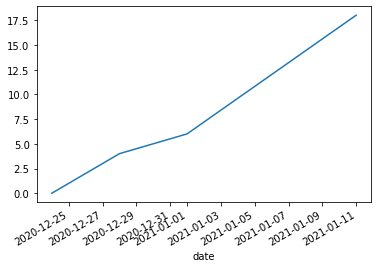

In [69]:
df['event_points'][-4:].plot()

#### Not only trend is increasing but the form is the max of all forms for Saka

## Trend in teams

In [70]:
next_matches_strength = pd.read_csv('/Users/ziadNader/Desktop/Personal Projects/Fantasy Premier League/Scripts/Data Collection/Football APIs/next_matches_strength_110121.csv')

In [71]:
next_matches_strength

,Unnamed: 0,home,away,status,date_x,matchday_x,name_x,strength_overall_home,strength_attack_home,strength_defence_home,date_y,matchday_y,name_y,strength_overall_away,strength_attack_away,strength_defence_away,overall_diff,attack_diff,defence_diff
0,0,Sheffield United FC,Newcastle United FC,SCHEDULED,2021-01-12T18:00:00Z,18,Sheffield United FC,1070,1110,1010,2021-01-12T18:00:00Z,18,Newcastle United FC,1130,1120,1060,-60,50,-110
1,1,Sheffield United FC,Tottenham Hotspur FC,SCHEDULED,2021-01-17T14:00:00Z,19,Sheffield United FC,1070,1110,1010,2021-01-17T14:00:00Z,19,Tottenham Hotspur FC,1280,1240,1320,-210,-210,-230
2,2,Sheffield United FC,West Bromwich Albion FC,SCHEDULED,2021-02-02T19:45:00Z,22,Sheffield United FC,1070,1110,1010,2021-02-02T19:45:00Z,22,West Bromwich Albion FC,1030,1020,1010,40,100,-10
3,3,Wolverhampton Wanderers FC,Everton FC,SCHEDULED,2021-01-12T20:15:00Z,18,Wolverhampton Wanderers FC,1160,1180,1100,2021-01-12T20:15:00Z,18,Everton FC,1210,1170,1250,-50,-70,-70
4,4,Wolverhampton Wanderers FC,West Bromwich Albion FC,SCHEDULED,2021-01-16T12:30:00Z,19,Wolverhampton Wanderers FC,1160,1180,1100,2021-01-16T12:30:00Z,19,West Bromwich Albion FC,1030,1020,1010,130,170,80
5,5,Wolverhampton Wanderers FC,Arsenal FC,SCHEDULED,2021-02-02T19:45:00Z,22,Wolverhampton Wanderers FC,1160,1180,1100,2021-02-02T19:45:00Z,22,Arsenal FC,1210,1210,1200,-50,-20,-110
6,6,Manchester City FC,Brighton & Hove Albion FC,SCHEDULED,2021-01-13T18:00:00Z,18,Manchester City FC,1310,1260,1330,2021-01-13T18:00:00Z,18,Brighton & Hove Albion FC,1100,1180,1100,210,160,150
7,7,Manchester City FC,Crystal Palace FC,SCHEDULED,2021-01-17T19:15:00Z,19,Manchester City FC,1310,1260,1330,2021-01-17T19:15:00Z,19,Crystal Palace FC,1150,1150,1050,160,210,180
8,8,Manchester City FC,Sheffield United FC,SCHEDULED,2021-01-30T15:00:00Z,21,Manchester City FC,1310,1260,1330,2021-01-30T15:00:00Z,21,Sheffield United FC,1100,1130,1050,210,210,200
9,9,Aston Villa FC,Tottenham Hotspur FC,SCHEDULED,2021-01-13T20:15:00Z,18,Aston Villa FC,1150,1150,1180,2021-01-13T20:15:00Z,18,Tottenham Hotspur FC,1280,1240,1320,-130,-170,-60


In [72]:
overall_strength = pd.read_json("/Users/ziadNader/Desktop/Personal Projects/Fantasy Premier League/Scripts/Data Collection/Football APIs/overall_strength_df_100121.json")

In [73]:
overall_strength.sort_values(by='strength_index')

,team,strength_index
3,Burnley FC,0.000000
7,Fulham FC,0.046729
17,West Bromwich Albion FC,0.121495
2,Brighton & Hove Albion FC,0.154206
14,Sheffield United FC,0.154206
5,Crystal Palace FC,0.285047
8,Leeds United FC,0.303738
13,Newcastle United FC,0.359813
1,Aston Villa FC,0.378505
15,Southampton FC,0.383178


In [74]:
players_df.date

0       2020-10-01
1       2020-10-01
2       2020-10-01
3       2020-10-01
4       2020-10-01
           ...    
10641   2020-08-26
10642   2020-08-26
10643   2020-08-26
10644   2020-08-26
10645   2020-08-26
Name: date, Length: 10646, dtype: datetime64[ns]

In [75]:
total_df = pd.merge(players_df, teams_df, how='left',
                    left_on='team_code', right_on='code')

In [76]:
total_df

,assists,bonus,bps,chance_of_playing_next_round,chance_of_playing_this_round,clean_sheets,code_x,cost_change_event,cost_change_event_fall,cost_change_start,cost_change_start_fall,creativity,dreamteam_count,element_type,ep_next,ep_this,event_points,first_name,form,goals_conceded,goals_scored,ict_index,i_d,in_dreamteam,influence,minutes,news,news_added,now_cost,own_goals,...,second_name,selected_by_percent,special,squad_number,status,team,team_code,threat,total_points,transfers_in,transfers_in_event,transfers_out,transfers_out_event,value_form,value_season,web_name,yellow_cards,date_x,id,code_y,name,strength,short_name,strength_overall_home,strength_overall_away,strength_attack_home,strength_attack_away,strength_defence_home,strength_defence_away,date_y
0,0,0,0,NaN,NaN,0,37605,-1,1,-2,2,0.0,0,3,0.5,-0.5,0,Mesut,0.0,0,0,0.0,1,0,0.0,0,None,None,68,0,...,Özil,0.8,0,None,a,1,3,0.0,0,2157,487,33983,4034,0.0,0.0,Özil,0,2020-10-01,1.0,3.0,Arsenal,4.0,ARS,1190.0,1210.0,1170.0,1210.0,1190.0,1200.0,2020-12-28 00:00:00
1,0,0,0,NaN,NaN,0,37605,-1,1,-2,2,0.0,0,3,0.5,-0.5,0,Mesut,0.0,0,0,0.0,1,0,0.0,0,None,None,68,0,...,Özil,0.8,0,None,a,1,3,0.0,0,2157,487,33983,4034,0.0,0.0,Özil,0,2020-10-01,1.0,3.0,Arsenal,4.0,ARS,1190.0,1210.0,1170.0,1210.0,1190.0,1200.0,2020-12-10 00:00:00
2,0,0,0,NaN,NaN,0,37605,-1,1,-2,2,0.0,0,3,0.5,-0.5,0,Mesut,0.0,0,0,0.0,1,0,0.0,0,None,None,68,0,...,Özil,0.8,0,None,a,1,3,0.0,0,2157,487,33983,4034,0.0,0.0,Özil,0,2020-10-01,1.0,3.0,Arsenal,4.0,ARS,1190.0,1210.0,1170.0,1210.0,1190.0,1200.0,2021-01-11 00:00:00
3,0,0,0,NaN,NaN,0,37605,-1,1,-2,2,0.0,0,3,0.5,-0.5,0,Mesut,0.0,0,0,0.0,1,0,0.0,0,None,None,68,0,...,Özil,0.8,0,None,a,1,3,0.0,0,2157,487,33983,4034,0.0,0.0,Özil,0,2020-10-01,1.0,3.0,Arsenal,4.0,ARS,1190.0,1270.0,1190.0,1200.0,1160.0,1270.0,2020-10-01 00:00:00
4,0,0,0,NaN,NaN,0,37605,-1,1,-2,2,0.0,0,3,0.5,-0.5,0,Mesut,0.0,0,0,0.0,1,0,0.0,0,None,None,68,0,...,Özil,0.8,0,None,a,1,3,0.0,0,2157,487,33983,4034,0.0,0.0,Özil,0,2020-10-01,1.0,3.0,Arsenal,4.0,ARS,1190.0,1270.0,1190.0,1200.0,1160.0,1270.0,2020-07-31 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179425,0,0,0,NaN,NaN,0,474003,0,0,0,0,0.0,0,4,1.3,NaN,0,Leonardo,0.0,0,0,0.0,476,0,0.0,0,None,None,50,0,...,Campana,0.3,0,None,a,20,39,0.0,0,0,0,0,0,0.0,0.0,Campana,0,2020-08-26,20.0,39.0,Wolves,3.0,WOL,1200.0,1190.0,1230.0,1250.0,1170.0,1200.0,2020-10-05 00:00:00
179426,0,0,0,NaN,NaN,0,474003,0,0,0,0,0.0,0,4,1.3,NaN,0,Leonardo,0.0,0,0,0.0,476,0,0.0,0,None,None,50,0,...,Campana,0.3,0,None,a,20,39,0.0,0,0,0,0,0,0.0,0.0,Campana,0,2020-08-26,20.0,39.0,Wolves,3.0,WOL,1160.0,1190.0,1180.0,1220.0,1100.0,1170.0,2021-01-01 00:00:00
179427,0,0,0,NaN,NaN,0,474003,0,0,0,0,0.0,0,4,1.3,NaN,0,Leonardo,0.0,0,0,0.0,476,0,0.0,0,None,None,50,0,...,Campana,0.3,0,None,a,20,39,0.0,0,0,0,0,0,0.0,0.0,Campana,0,2020-08-26,20.0,39.0,Wolves,3.0,WOL,1160.0,1190.0,1180.0,1220.0,1100.0,1170.0,2020-12-18 00:00:00
179428,0,0,0,NaN,NaN,0,474003,0,0,0,0,0.0,0,4,1.3,NaN,0,Leonardo,0.0,0,0,0.0,476,0,0.0,0,None,None,50,0,...,Campana,0.3,0,None,a,20,39,0.0,0,0,0,0,0,0.0,0.0,Campana,0,2020-08-26,20.0,39.0,Wolves,3.0,WOL,1200.0,1190.0,1230.0,1250.0,1170.0,1200.0,2020-10-16 00:00:00


In [77]:
dict_team_names = {'Arsenal': 'Arsenal FC', 
                   'Aston Villa' : 'Aston Villa FC',
                   'Brighton' : 'Brighton & Hove Albion FC',
                   'Burnley' : 'Burnley FC',
                   'Chelsea' : 'Chelsea FC',
                   'Crystal Palace' : 'Crystal Palace FC',
                   'Everton' : 'Everton FC',
                   'Fulham' : 'Fulham FC',
                   'Leicester' : 'Leicester City FC',
                   'Leeds' : 'Leeds United FC',
                   'Liverpool' : 'Liverpool FC',
                   'Man City' : 'Manchester City FC',
                   'Man Utd' : 'Manchester United FC',
                   'Newcastle' : 'Newcastle United FC',
                   'Sheffield Utd': 'Sheffield United FC',
                   'Southampton': 'Southampton FC',
                   'Spurs': 'Tottenham Hotspur FC',
                   'West Brom': 'West Bromwich Albion FC',
                   'West Ham': 'West Ham United FC',
                   'Wolves': 'Wolverhampton Wanderers FC'	}

In [78]:
total_df.name = total_df.name.map(dict_team_names)

In [79]:
total_df

,assists,bonus,bps,chance_of_playing_next_round,chance_of_playing_this_round,clean_sheets,code_x,cost_change_event,cost_change_event_fall,cost_change_start,cost_change_start_fall,creativity,dreamteam_count,element_type,ep_next,ep_this,event_points,first_name,form,goals_conceded,goals_scored,ict_index,i_d,in_dreamteam,influence,minutes,news,news_added,now_cost,own_goals,...,second_name,selected_by_percent,special,squad_number,status,team,team_code,threat,total_points,transfers_in,transfers_in_event,transfers_out,transfers_out_event,value_form,value_season,web_name,yellow_cards,date_x,id,code_y,name,strength,short_name,strength_overall_home,strength_overall_away,strength_attack_home,strength_attack_away,strength_defence_home,strength_defence_away,date_y
0,0,0,0,NaN,NaN,0,37605,-1,1,-2,2,0.0,0,3,0.5,-0.5,0,Mesut,0.0,0,0,0.0,1,0,0.0,0,None,None,68,0,...,Özil,0.8,0,None,a,1,3,0.0,0,2157,487,33983,4034,0.0,0.0,Özil,0,2020-10-01,1.0,3.0,Arsenal FC,4.0,ARS,1190.0,1210.0,1170.0,1210.0,1190.0,1200.0,2020-12-28 00:00:00
1,0,0,0,NaN,NaN,0,37605,-1,1,-2,2,0.0,0,3,0.5,-0.5,0,Mesut,0.0,0,0,0.0,1,0,0.0,0,None,None,68,0,...,Özil,0.8,0,None,a,1,3,0.0,0,2157,487,33983,4034,0.0,0.0,Özil,0,2020-10-01,1.0,3.0,Arsenal FC,4.0,ARS,1190.0,1210.0,1170.0,1210.0,1190.0,1200.0,2020-12-10 00:00:00
2,0,0,0,NaN,NaN,0,37605,-1,1,-2,2,0.0,0,3,0.5,-0.5,0,Mesut,0.0,0,0,0.0,1,0,0.0,0,None,None,68,0,...,Özil,0.8,0,None,a,1,3,0.0,0,2157,487,33983,4034,0.0,0.0,Özil,0,2020-10-01,1.0,3.0,Arsenal FC,4.0,ARS,1190.0,1210.0,1170.0,1210.0,1190.0,1200.0,2021-01-11 00:00:00
3,0,0,0,NaN,NaN,0,37605,-1,1,-2,2,0.0,0,3,0.5,-0.5,0,Mesut,0.0,0,0,0.0,1,0,0.0,0,None,None,68,0,...,Özil,0.8,0,None,a,1,3,0.0,0,2157,487,33983,4034,0.0,0.0,Özil,0,2020-10-01,1.0,3.0,Arsenal FC,4.0,ARS,1190.0,1270.0,1190.0,1200.0,1160.0,1270.0,2020-10-01 00:00:00
4,0,0,0,NaN,NaN,0,37605,-1,1,-2,2,0.0,0,3,0.5,-0.5,0,Mesut,0.0,0,0,0.0,1,0,0.0,0,None,None,68,0,...,Özil,0.8,0,None,a,1,3,0.0,0,2157,487,33983,4034,0.0,0.0,Özil,0,2020-10-01,1.0,3.0,Arsenal FC,4.0,ARS,1190.0,1270.0,1190.0,1200.0,1160.0,1270.0,2020-07-31 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179425,0,0,0,NaN,NaN,0,474003,0,0,0,0,0.0,0,4,1.3,NaN,0,Leonardo,0.0,0,0,0.0,476,0,0.0,0,None,None,50,0,...,Campana,0.3,0,None,a,20,39,0.0,0,0,0,0,0,0.0,0.0,Campana,0,2020-08-26,20.0,39.0,Wolverhampton Wanderers FC,3.0,WOL,1200.0,1190.0,1230.0,1250.0,1170.0,1200.0,2020-10-05 00:00:00
179426,0,0,0,NaN,NaN,0,474003,0,0,0,0,0.0,0,4,1.3,NaN,0,Leonardo,0.0,0,0,0.0,476,0,0.0,0,None,None,50,0,...,Campana,0.3,0,None,a,20,39,0.0,0,0,0,0,0,0.0,0.0,Campana,0,2020-08-26,20.0,39.0,Wolverhampton Wanderers FC,3.0,WOL,1160.0,1190.0,1180.0,1220.0,1100.0,1170.0,2021-01-01 00:00:00
179427,0,0,0,NaN,NaN,0,474003,0,0,0,0,0.0,0,4,1.3,NaN,0,Leonardo,0.0,0,0,0.0,476,0,0.0,0,None,None,50,0,...,Campana,0.3,0,None,a,20,39,0.0,0,0,0,0,0,0.0,0.0,Campana,0,2020-08-26,20.0,39.0,Wolverhampton Wanderers FC,3.0,WOL,1160.0,1190.0,1180.0,1220.0,1100.0,1170.0,2020-12-18 00:00:00
179428,0,0,0,NaN,NaN,0,474003,0,0,0,0,0.0,0,4,1.3,NaN,0,Leonardo,0.0,0,0,0.0,476,0,0.0,0,None,None,50,0,...,Campana,0.3,0,None,a,20,39,0.0,0,0,0,0,0,0.0,0.0,Campana,0,2020-08-26,20.0,39.0,Wolverhampton Wanderers FC,3.0,WOL,1200.0,1190.0,1230.0,1250.0,1170.0,1200.0,2020-10-16 00:00:00


In [80]:
total_df_test = pd.merge(total_df, overall_strength,
                    left_on='name', right_on='team')

In [81]:
total_df_test.isna().sum()

assists                              0
bonus                                0
bps                                  0
chance_of_playing_next_round     87312
chance_of_playing_this_round     92310
clean_sheets                         0
code_x                               0
cost_change_event                    0
cost_change_event_fall               0
cost_change_start                    0
cost_change_start_fall               0
creativity                           0
dreamteam_count                      0
element_type                         0
ep_next                              0
ep_this                          16983
event_points                         0
first_name                           0
form                                 0
goals_conceded                       0
goals_scored                         0
ict_index                            0
i_d                                  0
in_dreamteam                         0
influence                            0
minutes                  

In [92]:
total_df_test['roi'] = ((total_df_test['points_per_game'])
                   #* players_df_final['points_per_game']
                   * total_df_test['strength_index']
                   #* total_df_test['matchday_selection']
                   #* total_df_test['form']
                   * total_df_test['value_form']
                   / total_df_test['now_cost'])

In [93]:
total_df_test

,assists,bonus,bps,chance_of_playing_next_round,chance_of_playing_this_round,clean_sheets,code_x,cost_change_event,cost_change_event_fall,cost_change_start,cost_change_start_fall,creativity,dreamteam_count,element_type,ep_next,ep_this,event_points,first_name,form,goals_conceded,goals_scored,ict_index,i_d,in_dreamteam,influence,minutes,news,news_added,now_cost,own_goals,...,squad_number,status,team_x,team_code,threat,total_points,transfers_in,transfers_in_event,transfers_out,transfers_out_event,value_form,value_season,web_name,yellow_cards,date_x,id,code_y,name,strength,short_name,strength_overall_home,strength_overall_away,strength_attack_home,strength_attack_away,strength_defence_home,strength_defence_away,date_y,team_y,strength_index,roi
0,0,0,0,NaN,NaN,0,37605,-1,1,-2,2,0.0,0,3,0.5,-0.5,0,Mesut,0.0,0,0,0.0,1,0,0.0,0,None,None,68,0,...,None,a,1,3,0.0,0,2157,487,33983,4034,0.0,0.0,Özil,0,2020-10-01,1.0,3.0,Arsenal FC,4.0,ARS,1190.0,1210.0,1170.0,1210.0,1190.0,1200.0,2020-12-28 00:00:00,Arsenal FC,0.500000,0.0
1,0,0,0,NaN,NaN,0,37605,-1,1,-2,2,0.0,0,3,0.5,-0.5,0,Mesut,0.0,0,0,0.0,1,0,0.0,0,None,None,68,0,...,None,a,1,3,0.0,0,2157,487,33983,4034,0.0,0.0,Özil,0,2020-10-01,1.0,3.0,Arsenal FC,4.0,ARS,1190.0,1210.0,1170.0,1210.0,1190.0,1200.0,2020-12-10 00:00:00,Arsenal FC,0.500000,0.0
2,0,0,0,NaN,NaN,0,37605,-1,1,-2,2,0.0,0,3,0.5,-0.5,0,Mesut,0.0,0,0,0.0,1,0,0.0,0,None,None,68,0,...,None,a,1,3,0.0,0,2157,487,33983,4034,0.0,0.0,Özil,0,2020-10-01,1.0,3.0,Arsenal FC,4.0,ARS,1190.0,1210.0,1170.0,1210.0,1190.0,1200.0,2021-01-11 00:00:00,Arsenal FC,0.500000,0.0
3,0,0,0,NaN,NaN,0,37605,-1,1,-2,2,0.0,0,3,0.5,-0.5,0,Mesut,0.0,0,0,0.0,1,0,0.0,0,None,None,68,0,...,None,a,1,3,0.0,0,2157,487,33983,4034,0.0,0.0,Özil,0,2020-10-01,1.0,3.0,Arsenal FC,4.0,ARS,1190.0,1270.0,1190.0,1200.0,1160.0,1270.0,2020-10-01 00:00:00,Arsenal FC,0.500000,0.0
4,0,0,0,NaN,NaN,0,37605,-1,1,-2,2,0.0,0,3,0.5,-0.5,0,Mesut,0.0,0,0,0.0,1,0,0.0,0,None,None,68,0,...,None,a,1,3,0.0,0,2157,487,33983,4034,0.0,0.0,Özil,0,2020-10-01,1.0,3.0,Arsenal FC,4.0,ARS,1190.0,1270.0,1190.0,1200.0,1160.0,1270.0,2020-07-31 00:00:00,Arsenal FC,0.500000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179328,0,0,0,NaN,NaN,0,474003,0,0,0,0,0.0,0,4,1.3,NaN,0,Leonardo,0.0,0,0,0.0,476,0,0.0,0,None,None,50,0,...,None,a,20,39,0.0,0,0,0,0,0,0.0,0.0,Campana,0,2020-08-26,20.0,39.0,Wolverhampton Wanderers FC,3.0,WOL,1200.0,1190.0,1230.0,1250.0,1170.0,1200.0,2020-10-05 00:00:00,Wolverhampton Wanderers FC,0.439252,0.0
179329,0,0,0,NaN,NaN,0,474003,0,0,0,0,0.0,0,4,1.3,NaN,0,Leonardo,0.0,0,0,0.0,476,0,0.0,0,None,None,50,0,...,None,a,20,39,0.0,0,0,0,0,0,0.0,0.0,Campana,0,2020-08-26,20.0,39.0,Wolverhampton Wanderers FC,3.0,WOL,1160.0,1190.0,1180.0,1220.0,1100.0,1170.0,2021-01-01 00:00:00,Wolverhampton Wanderers FC,0.439252,0.0
179330,0,0,0,NaN,NaN,0,474003,0,0,0,0,0.0,0,4,1.3,NaN,0,Leonardo,0.0,0,0,0.0,476,0,0.0,0,None,None,50,0,...,None,a,20,39,0.0,0,0,0,0,0,0.0,0.0,Campana,0,2020-08-26,20.0,39.0,Wolverhampton Wanderers FC,3.0,WOL,1160.0,1190.0,1180.0,1220.0,1100.0,1170.0,2020-12-18 00:00:00,Wolverhampton Wanderers FC,0.439252,0.0
179331,0,0,0,NaN,NaN,0,474003,0,0,0,0,0.0,0,4,1.3,NaN,0,Leonardo,0.0,0,0,0.0,476,0,0.0,0,None,None,50,0,...,None,a,20,39,0.0,0,0,0,0,0,0.0,0.0,Campana,0,2020-08-26,20.0,39.0,Wolverhampton Wanderers FC,3.0,WOL,1200.0,1190.0,1230.0,1250.0,1170.0,1200.0,2020-10-16 00:00:00,Wolverhampton Wanderers FC,0.439252,0.0


In [96]:
total_df_test[total_df_test['web_name']=='De Bruyne']

,assists,bonus,bps,chance_of_playing_next_round,chance_of_playing_this_round,clean_sheets,code_x,cost_change_event,cost_change_event_fall,cost_change_start,cost_change_start_fall,creativity,dreamteam_count,element_type,ep_next,ep_this,event_points,first_name,form,goals_conceded,goals_scored,ict_index,i_d,in_dreamteam,influence,minutes,news,news_added,now_cost,own_goals,...,squad_number,status,team_x,team_code,threat,total_points,transfers_in,transfers_in_event,transfers_out,transfers_out_event,value_form,value_season,web_name,yellow_cards,date_x,id,code_y,name,strength,short_name,strength_overall_home,strength_overall_away,strength_attack_home,strength_attack_away,strength_defence_home,strength_defence_away,date_y,team_y,strength_index,roi
98787,1,3,55,NaN,NaN,0,61366,0,0,1,-1,114.1,0,3,9.0,8.0,2,Kevin,7.5,6,1,28.4,272,0,95.6,180,None,None,116,0,...,None,a,12,43,74.0,15,1401586,136681,267408,79586,0.6,1.3,De Bruyne,0,2020-10-01,12.0,43.0,Manchester City FC,5.0,MCI,1310.0,1360.0,1260.0,1320.0,1330.0,1350.0,2020-12-28 00:00:00,Manchester City FC,1.0,0.038793
98788,1,3,55,NaN,NaN,0,61366,0,0,1,-1,114.1,0,3,9.0,8.0,2,Kevin,7.5,6,1,28.4,272,0,95.6,180,None,None,116,0,...,None,a,12,43,74.0,15,1401586,136681,267408,79586,0.6,1.3,De Bruyne,0,2020-10-01,12.0,43.0,Manchester City FC,5.0,MCI,1310.0,1360.0,1260.0,1320.0,1330.0,1350.0,2020-12-10 00:00:00,Manchester City FC,1.0,0.038793
98789,1,3,55,NaN,NaN,0,61366,0,0,1,-1,114.1,0,3,9.0,8.0,2,Kevin,7.5,6,1,28.4,272,0,95.6,180,None,None,116,0,...,None,a,12,43,74.0,15,1401586,136681,267408,79586,0.6,1.3,De Bruyne,0,2020-10-01,12.0,43.0,Manchester City FC,5.0,MCI,1310.0,1360.0,1260.0,1320.0,1330.0,1350.0,2021-01-11 00:00:00,Manchester City FC,1.0,0.038793
98790,1,3,55,NaN,NaN,0,61366,0,0,1,-1,114.1,0,3,9.0,8.0,2,Kevin,7.5,6,1,28.4,272,0,95.6,180,None,None,116,0,...,None,a,12,43,74.0,15,1401586,136681,267408,79586,0.6,1.3,De Bruyne,0,2020-10-01,12.0,43.0,Manchester City FC,5.0,MCI,1310.0,1350.0,1250.0,1340.0,1340.0,1350.0,2020-10-01 00:00:00,Manchester City FC,1.0,0.038793
98791,1,3,55,NaN,NaN,0,61366,0,0,1,-1,114.1,0,3,9.0,8.0,2,Kevin,7.5,6,1,28.4,272,0,95.6,180,None,None,116,0,...,None,a,12,43,74.0,15,1401586,136681,267408,79586,0.6,1.3,De Bruyne,0,2020-10-01,12.0,43.0,Manchester City FC,5.0,MCI,1310.0,1350.0,1250.0,1340.0,1340.0,1350.0,2020-07-31 00:00:00,Manchester City FC,1.0,0.038793
98792,1,3,55,NaN,NaN,0,61366,0,0,1,-1,114.1,0,3,9.0,8.0,2,Kevin,7.5,6,1,28.4,272,0,95.6,180,None,None,116,0,...,None,a,12,43,74.0,15,1401586,136681,267408,79586,0.6,1.3,De Bruyne,0,2020-10-01,12.0,43.0,Manchester City FC,5.0,MCI,1310.0,1360.0,1260.0,1320.0,1330.0,1350.0,2020-12-04 00:00:00,Manchester City FC,1.0,0.038793
98793,1,3,55,NaN,NaN,0,61366,0,0,1,-1,114.1,0,3,9.0,8.0,2,Kevin,7.5,6,1,28.4,272,0,95.6,180,None,None,116,0,...,None,a,12,43,74.0,15,1401586,136681,267408,79586,0.6,1.3,De Bruyne,0,2020-10-01,12.0,43.0,Manchester City FC,5.0,MCI,1310.0,1360.0,1260.0,1320.0,1330.0,1350.0,2020-11-21 00:00:00,Manchester City FC,1.0,0.038793
98794,1,3,55,NaN,NaN,0,61366,0,0,1,-1,114.1,0,3,9.0,8.0,2,Kevin,7.5,6,1,28.4,272,0,95.6,180,None,None,116,0,...,None,a,12,43,74.0,15,1401586,136681,267408,79586,0.6,1.3,De Bruyne,0,2020-10-01,12.0,43.0,Manchester City FC,5.0,MCI,1310.0,1350.0,1250.0,1340.0,1340.0,1350.0,2020-08-26 00:00:00,Manchester City FC,1.0,0.038793
98795,1,3,55,NaN,NaN,0,61366,0,0,1,-1,114.1,0,3,9.0,8.0,2,Kevin,7.5,6,1,28.4,272,0,95.6,180,None,None,116,0,...,None,a,12,43,74.0,15,1401586,136681,267408,79586,0.6,1.3,De Bruyne,0,2020-10-01,12.0,43.0,Manchester City FC,5.0,MCI,1310.0,1360.0,1260.0,1320.0,1330.0,1350.0,2020-11-27 00:00:00,Manchester City FC,1.0,0.038793
98796,1,3,55,NaN,NaN,0,61366,0,0,1,-1,114.1,0,3,9.0,8.0,2,Kevin,7.5,6,1,28.4,272,0,95.6,180,None,None,116,0,...,None,a,12,43,74.0,15,1401586,136681,267408,79586,0.6,1.3,De Bruyne,0,2020-10-01,12.0,43.0,Manchester City FC,5.0,MCI,1310.0,1360.0,1260.0,1320.0,1330.0,1350.0,2020-12-24 00:00:00,Manchester City FC,1.0,0.038793


In [97]:
total_df_test[total_df_test['web_name']=='Salah']

,assists,bonus,bps,chance_of_playing_next_round,chance_of_playing_this_round,clean_sheets,code_x,cost_change_event,cost_change_event_fall,cost_change_start,cost_change_start_fall,creativity,dreamteam_count,element_type,ep_next,ep_this,event_points,first_name,form,goals_conceded,goals_scored,ict_index,i_d,in_dreamteam,influence,minutes,news,news_added,now_cost,own_goals,...,squad_number,status,team_x,team_code,threat,total_points,transfers_in,transfers_in_event,transfers_out,transfers_out_event,value_form,value_season,web_name,yellow_cards,date_x,id,code_y,name,strength,short_name,strength_overall_home,strength_overall_away,strength_attack_home,strength_attack_away,strength_defence_home,strength_defence_away,date_y,team_y,strength_index,roi
89998,1,3,101,NaN,NaN,1,118748,0,0,1,-1,138.9,1,3,10.8,9.8,5,Mohamed,9.3,4,3,53.4,254,1,139.6,270,None,None,121,0,...,None,a,11,14,256.0,28,678763,135406,330357,39155,0.8,2.3,Salah,0,2020-10-01,11.0,14.0,Liverpool FC,5.0,LIV,1320.0,1360.0,1240.0,1320.0,1330.0,1350.0,2020-12-28 00:00:00,Liverpool FC,0.82243,0.050569
89999,1,3,101,NaN,NaN,1,118748,0,0,1,-1,138.9,1,3,10.8,9.8,5,Mohamed,9.3,4,3,53.4,254,1,139.6,270,None,None,121,0,...,None,a,11,14,256.0,28,678763,135406,330357,39155,0.8,2.3,Salah,0,2020-10-01,11.0,14.0,Liverpool FC,5.0,LIV,1320.0,1360.0,1240.0,1320.0,1330.0,1350.0,2020-12-10 00:00:00,Liverpool FC,0.82243,0.050569
90000,1,3,101,NaN,NaN,1,118748,0,0,1,-1,138.9,1,3,10.8,9.8,5,Mohamed,9.3,4,3,53.4,254,1,139.6,270,None,None,121,0,...,None,a,11,14,256.0,28,678763,135406,330357,39155,0.8,2.3,Salah,0,2020-10-01,11.0,14.0,Liverpool FC,5.0,LIV,1320.0,1360.0,1240.0,1320.0,1330.0,1350.0,2021-01-11 00:00:00,Liverpool FC,0.82243,0.050569
90001,1,3,101,NaN,NaN,1,118748,0,0,1,-1,138.9,1,3,10.8,9.8,5,Mohamed,9.3,4,3,53.4,254,1,139.6,270,None,None,121,0,...,None,a,11,14,256.0,28,678763,135406,330357,39155,0.8,2.3,Salah,0,2020-10-01,11.0,14.0,Liverpool FC,5.0,LIV,1320.0,1350.0,1280.0,1320.0,1300.0,1340.0,2020-10-01 00:00:00,Liverpool FC,0.82243,0.050569
90002,1,3,101,NaN,NaN,1,118748,0,0,1,-1,138.9,1,3,10.8,9.8,5,Mohamed,9.3,4,3,53.4,254,1,139.6,270,None,None,121,0,...,None,a,11,14,256.0,28,678763,135406,330357,39155,0.8,2.3,Salah,0,2020-10-01,11.0,14.0,Liverpool FC,5.0,LIV,1320.0,1350.0,1280.0,1320.0,1300.0,1340.0,2020-07-31 00:00:00,Liverpool FC,0.82243,0.050569
90003,1,3,101,NaN,NaN,1,118748,0,0,1,-1,138.9,1,3,10.8,9.8,5,Mohamed,9.3,4,3,53.4,254,1,139.6,270,None,None,121,0,...,None,a,11,14,256.0,28,678763,135406,330357,39155,0.8,2.3,Salah,0,2020-10-01,11.0,14.0,Liverpool FC,5.0,LIV,1320.0,1360.0,1240.0,1320.0,1330.0,1350.0,2020-12-04 00:00:00,Liverpool FC,0.82243,0.050569
90004,1,3,101,NaN,NaN,1,118748,0,0,1,-1,138.9,1,3,10.8,9.8,5,Mohamed,9.3,4,3,53.4,254,1,139.6,270,None,None,121,0,...,None,a,11,14,256.0,28,678763,135406,330357,39155,0.8,2.3,Salah,0,2020-10-01,11.0,14.0,Liverpool FC,5.0,LIV,1320.0,1360.0,1240.0,1320.0,1330.0,1350.0,2020-11-21 00:00:00,Liverpool FC,0.82243,0.050569
90005,1,3,101,NaN,NaN,1,118748,0,0,1,-1,138.9,1,3,10.8,9.8,5,Mohamed,9.3,4,3,53.4,254,1,139.6,270,None,None,121,0,...,None,a,11,14,256.0,28,678763,135406,330357,39155,0.8,2.3,Salah,0,2020-10-01,11.0,14.0,Liverpool FC,5.0,LIV,1320.0,1350.0,1280.0,1320.0,1300.0,1340.0,2020-08-26 00:00:00,Liverpool FC,0.82243,0.050569
90006,1,3,101,NaN,NaN,1,118748,0,0,1,-1,138.9,1,3,10.8,9.8,5,Mohamed,9.3,4,3,53.4,254,1,139.6,270,None,None,121,0,...,None,a,11,14,256.0,28,678763,135406,330357,39155,0.8,2.3,Salah,0,2020-10-01,11.0,14.0,Liverpool FC,5.0,LIV,1320.0,1360.0,1240.0,1320.0,1330.0,1350.0,2020-11-27 00:00:00,Liverpool FC,0.82243,0.050569
90007,1,3,101,NaN,NaN,1,118748,0,0,1,-1,138.9,1,3,10.8,9.8,5,Mohamed,9.3,4,3,53.4,254,1,139.6,270,None,None,121,0,...,None,a,11,14,256.0,28,678763,135406,330357,39155,0.8,2.3,Salah,0,2020-10-01,11.0,14.0,Liverpool FC,5.0,LIV,1320.0,1360.0,1240.0,1320.0,1330.0,1350.0,2020-12-24 00:00:00,Liverpool FC,0.82243,0.050569


In [95]:
players_df_2021[players_df_2021['web_name']=='De Bruyne'].loc[players_df_ts.index.max()]

assists                                                   8
bonus                                                    11
bps                                                     302
chance_of_playing_next_round                            100
chance_of_playing_this_round                            100
clean_sheets                                              7
code                                                  61366
cost_change_event                                         0
cost_change_event_fall                                    0
cost_change_start                                         2
cost_change_start_fall                                   -2
creativity                                            649.6
dreamteam_count                                           2
element_type                                              3
ep_next                                                 6.6
ep_this                                                 6.1
event_points                            